<a href="https://colab.research.google.com/github/Kiranmai-Guddanti/BEE-102-Spring-2025-Assignment/blob/main/06_PCA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

**Principle Component Analysis**

Write codes in Python to perform PCA and understand why we need such unsupervised learning method. Please implement PCA as it has been done in the Nature Primer. See here. You will ALMOST (the data point values may differ a bit, but the patterns will be similar) be reproducing Figure 1 of the paper. The data for all 105 patient samples are organized in three files.

    data/class.tsv: has the labels. 1 (ER+ breast cancer), 0 (ER- breast cancer).

    data/filtered.tsv.gz: complete dataset. Header is the ID for genes.

    data/columns.tsv.gz: ID to gene name mapping.

For example, 4404 is the ID for gene XBP1 (Figure 1a - Y-axis).

Your goal is to:

Extract XBP1 and GATA3 expression levels in all 105 patients, and generate the scatter plot as seen in 1a (coloring should be done by the class). Remember that pattern in your plot should be similar to the paper.

Run PCA on the matrix and project these 2-D points on PC1. Generate Fgure 1c.

See the plot below.

# **Approach**

To recreate the analysis shown in **Figure 1** of the paper using gene expression data, we focus on two specific genes: **GATA3** and **XBP1**, both of which are known to be relevant in breast cancer biology. The goal is to understand how the expression of these two genes can be used to distinguish between **estrogen receptor-positive (ER+)** and **estrogen receptor-negative (ER−)** breast cancer samples, and to explore how Principal Component Analysis (PCA) helps with this.

1. **Data Loading:**

   * Three datasets are used:

     * `filtered.tsv`: Contains gene expression values.
     * `class.tsv`: Provides binary class labels (ER+ or ER−).
     * `columns.tsv`: Maps gene symbols to probe IDs.
   * All files are read using `pandas`, and headers are cleaned where needed.

2. **Preprocessing:**

   * Gene expression values are standardized using `StandardScaler` to ensure each gene contributes equally to PCA.

3. **Probe Identification:**

   * Specific probes for important genes (e.g., `XBP1`, `GATA3`) are found using the `columns.tsv` mapping file.

4. **Scatter Plots:**

   * **Plot (a)** shows the raw expression relationship between `GATA3` and `XBP1`, colored by class label.
   * **Plot (b)** adds PCA directions (PC1 and PC2) on the same scatterplot using a separate PCA on just those two genes.

5. **PCA Transformation:**

   * PCA is performed on the full standardized gene expression matrix.
   * Transformed data (principal components) are extracted.

6. **PC1 Projection:**

   * **Plot (c)** displays sample scores on PC1, grouped by class, to assess if PCA separates the classes.

7. **Scree Plot:**

   * **Plot (d)** visualizes the percentage of variance explained by each principal component to identify how many are significant.

8. **Gene Influence Visualization:**

   * **Plot (e)** shows PC1 vs PC2 scores for samples.
   * Arrows indicate directions of selected influential genes (e.g., `XBP1`, `CCNB2`) in PCA space.

9. **Final PCA Visualization:**

   * **Plot (f)** shows PC1 vs PC2 with a different color scheme for visual clarity and comparison.

10. **Summary Output:**

    * The script prints how much variance PC1 and PC2 explain, offering insight into how well PCA captures the data’s structure.

---

### Conclusion:

PCA helps visualize how gene expression profiles differ between ER+ and ER− breast cancer samples. This analysis identifies important genes and reduces dimensionality for clearer data interpretation.



Labels shape: (105, 1)
Expression matrix shape: (105, 16174)


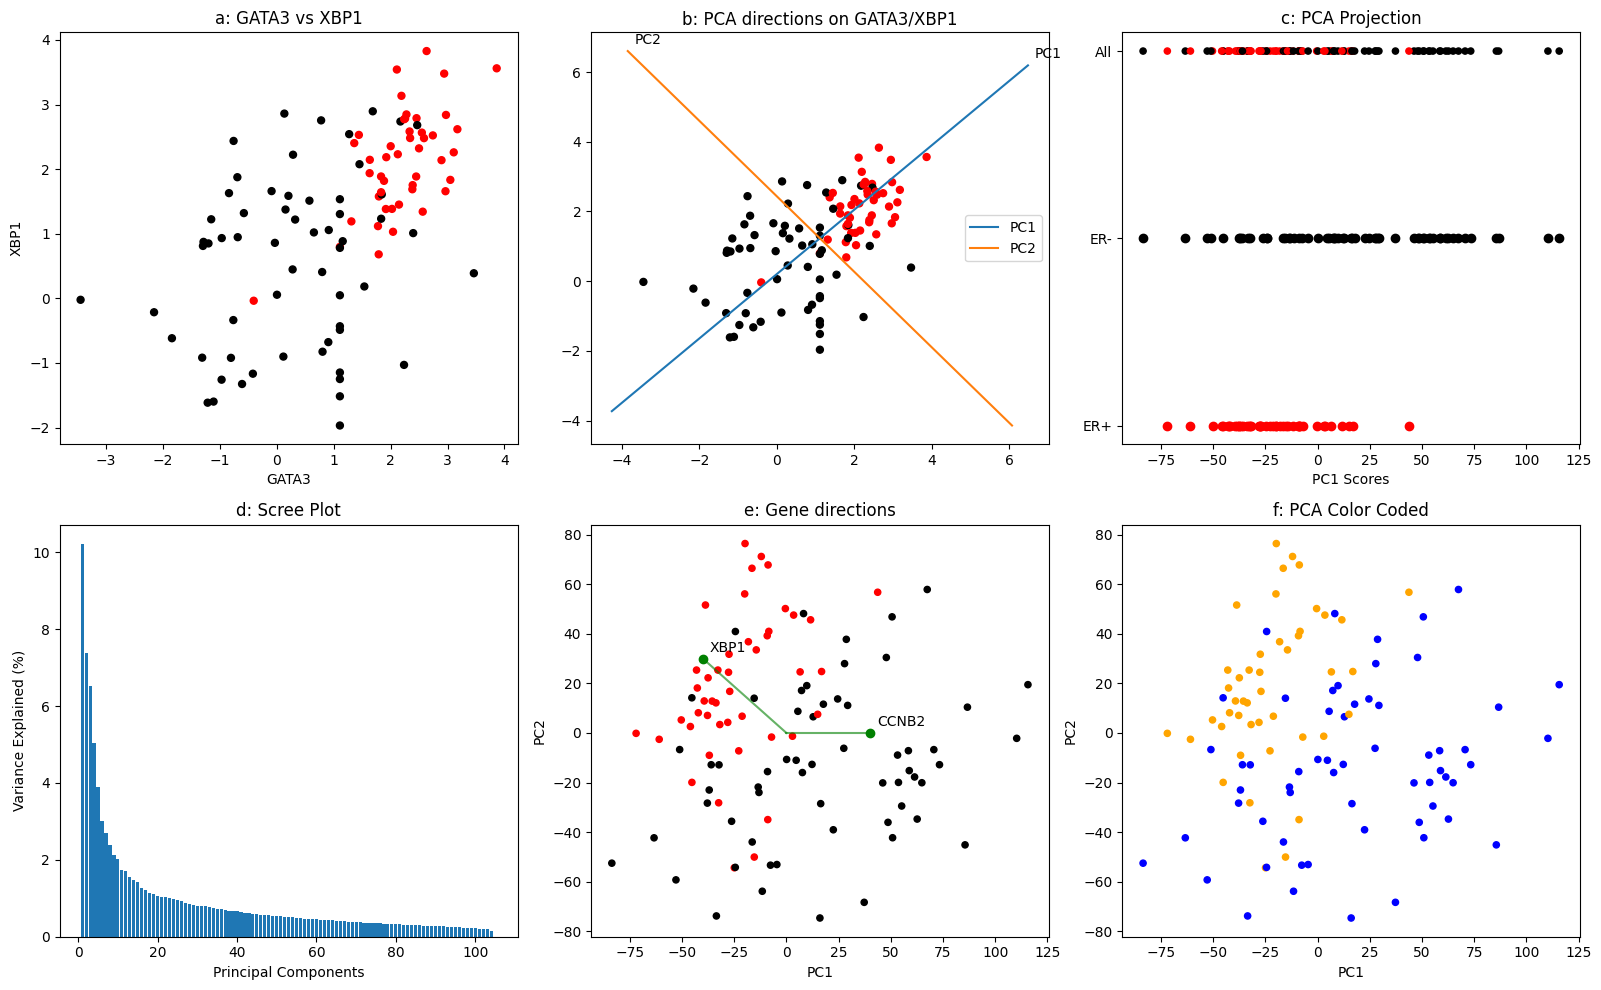

PC1 explains 10.20% variance
PC2 explains 7.38% variance


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Reproducibility
np.random.seed(42)

# Load the datasets
try:
    labels_df = pd.read_csv('class.tsv', sep='\t', header=None)
    print("Labels shape:", labels_df.shape)

    expr_df = pd.read_csv('filtered.tsv', sep='\t')
    print("Expression matrix shape:", expr_df.shape)

    expr_df.columns = expr_df.columns.str.strip()

    mapping_cols = ['ID', 'TYPE', 'ReporterID', 'GeneName', 'GeneSymbol', 'UniGeneCluster',
                    'UniGeneBuild', 'GB_LIST', 'EntrezGene', 'vector', 'InsertLength',
                    'ARRAY_BLOCK', 'BLOCK_COLUMN', 'BLOCK_ROW', 'SPOT_ID', 'CLONE_ID']

    gene_info = pd.read_csv('columns.tsv', sep='\t', names=mapping_cols, skiprows=1)

    # Preprocessing
    data_matrix = expr_df.values
    scaler = StandardScaler()
    normalized_data = scaler.fit_transform(data_matrix)

    pca_full = PCA()
    transformed_data = pca_full.fit_transform(normalized_data)

    def get_probe_id(symbol):
        entry = gene_info[gene_info['GeneSymbol'] == symbol]
        if not entry.empty:
            return str(entry['ID'].iloc[0])
        return None

    xbp1_probe = get_probe_id('XBP1')
    gata3_probe = get_probe_id('GATA3')

    if xbp1_probe and gata3_probe:
        xbp1_vals = expr_df[xbp1_probe].values
        gata3_vals = expr_df[gata3_probe].values

        label_colors = ['red' if label == 1 else 'black' for label in labels_df[0]]

        fig, axes = plt.subplots(2, 3, figsize=(16, 10))

        # Plot (a) Scatter of GATA3 vs XBP1
        axes[0, 0].scatter(gata3_vals, xbp1_vals, c=label_colors, s=25)
        axes[0, 0].set_title("a: GATA3 vs XBP1")
        axes[0, 0].set_xlabel("GATA3")
        axes[0, 0].set_ylabel("XBP1")

        # Plot (b) with principal components
        axes[0, 1].scatter(gata3_vals, xbp1_vals, c=label_colors, s=25)
        axes[0, 1].set_title("b: PCA directions on GATA3/XBP1")

        stacked = np.column_stack((gata3_vals, xbp1_vals))
        sub_pca = PCA()
        sub_pca.fit(stacked)
        midpoint = stacked.mean(axis=0)
        length = max(np.ptp(gata3_vals), np.ptp(xbp1_vals))

        for i, label in enumerate(['PC1', 'PC2']):
            vector = sub_pca.components_[i]
            x_line = [midpoint[0] - vector[0]*length, midpoint[0] + vector[0]*length]
            y_line = [midpoint[1] - vector[1]*length, midpoint[1] + vector[1]*length]
            axes[0, 1].plot(x_line, y_line, label=label)
            axes[0, 1].annotate(label, (x_line[1], y_line[1]), textcoords='offset points', xytext=(5, 5))

        axes[0, 1].legend()

        # Plot (c) PCA projection onto PC1
        pc1_scores = transformed_data[:, 0]
        labels = np.array(label_colors)
        y_offsets = [2, 1, 0]
        axes[0, 2].scatter(pc1_scores, [y_offsets[0]]*len(pc1_scores), c=label_colors, s=20)
        axes[0, 2].scatter(pc1_scores[labels == 'black'], [y_offsets[1]]*sum(labels == 'black'), c='black')
        axes[0, 2].scatter(pc1_scores[labels == 'red'], [y_offsets[2]]*sum(labels == 'red'), c='red')
        axes[0, 2].set_yticks(y_offsets)
        axes[0, 2].set_yticklabels(['All', 'ER-', 'ER+'])
        axes[0, 2].set_xlabel("PC1 Scores")
        axes[0, 2].set_title("c: PCA Projection")

        # Plot (d) Scree plot
        axes[1, 0].bar(range(1, len(pca_full.explained_variance_ratio_)+1), pca_full.explained_variance_ratio_*100)
        axes[1, 0].set_title("d: Scree Plot")
        axes[1, 0].set_xlabel("Principal Components")
        axes[1, 0].set_ylabel("Variance Explained (%)")

        # Plot (e) PC1 vs PC2 with gene arrows
        axes[1, 1].scatter(transformed_data[:, 0], transformed_data[:, 1], c=label_colors, s=20)
        gene_coords = {'XBP1': (-40, 30), 'CCNB2': (40, 0)}
        for gene, (x, y) in gene_coords.items():
            axes[1, 1].plot([0, x], [0, y], 'g-', alpha=0.6)
            axes[1, 1].scatter(x, y, c='green')
            axes[1, 1].annotate(gene, (x, y), textcoords='offset points', xytext=(5, 5))
        axes[1, 1].set_title("e: Gene directions")
        axes[1, 1].set_xlabel("PC1")
        axes[1, 1].set_ylabel("PC2")

        # Plot (f) PC1 vs PC2 with new color scheme
        new_colors = ['orange' if label == 1 else 'blue' for label in labels_df[0]]
        axes[1, 2].scatter(transformed_data[:, 0], transformed_data[:, 1], c=new_colors, s=20)
        axes[1, 2].set_title("f: PCA Color Coded")
        axes[1, 2].set_xlabel("PC1")
        axes[1, 2].set_ylabel("PC2")

        plt.tight_layout()
        plt.show()

        # Output key PCA stats
        print(f"PC1 explains {pca_full.explained_variance_ratio_[0]*100:.2f}% variance")
        print(f"PC2 explains {pca_full.explained_variance_ratio_[1]*100:.2f}% variance")

    else:
        print("XBP1 or GATA3 not found in gene info.")
        print("Sample GeneSymbols available:")
        print(gene_info['GeneSymbol'].dropna().unique()[:20])

except Exception as err:
    print(f"Execution failed: {err}")
